# OpenArm 2.0 Phase 2 — Google Drive Version

This notebook is rewritten to use this persistent Google Drive path:

```text
/content/drive/MyDrive/Colab Notebooks
```

It stores the project repo, input zips, generated outputs, and final submission zip in Google Drive instead of temporary `/content`.

Expected files in Google Drive:

```text
/content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline-phase2-colab.zip
/content/drive/MyDrive/Colab Notebooks/openarm_phase1_outputs.zip
```

The second file is optional, but useful if you want to compare Phase 1 and Phase 2 outputs.


## 1. Mount Google Drive and define paths


In [19]:
from pathlib import Path
import os, sys, json, zipfile, shutil, subprocess, textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

DRIVE_WORKDIR = Path("/content/drive/MyDrive/Colab Notebooks")
DRIVE_WORKDIR.mkdir(parents=True, exist_ok=True)

PROJECT_ZIP = DRIVE_WORKDIR / "openarm-data-pipeline-phase2-drive.zip"
PHASE1_ZIP = DRIVE_WORKDIR / "openarm_phase1_outputs.zip"
PROJECT_DIR = DRIVE_WORKDIR / "openarm-data-pipeline"

print("Drive workdir:", DRIVE_WORKDIR)
print("Project zip:", PROJECT_ZIP, "exists:", PROJECT_ZIP.exists())
print("Phase 1 zip:", PHASE1_ZIP, "exists:", PHASE1_ZIP.exists())
print("Project dir:", PROJECT_DIR, "exists:", PROJECT_DIR.exists())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive workdir: /content/drive/MyDrive/Colab Notebooks
Project zip: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline-phase2-drive.zip exists: True
Phase 1 zip: /content/drive/MyDrive/Colab Notebooks/openarm_phase1_outputs.zip exists: True
Project dir: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline exists: True


## 2. Upload zips into Google Drive if missing

Run this cell if the files are not already in:

```text
/content/drive/MyDrive/Colab Notebooks
```


In [20]:
from google.colab import files

missing = []
if not PROJECT_ZIP.exists():
    missing.append(PROJECT_ZIP.name)
if not PHASE1_ZIP.exists():
    missing.append(PHASE1_ZIP.name + " (optional)")

if missing:
    print("Missing files:", missing)
    print("Upload openarm-data-pipeline-phase2-drive.zip and optionally openarm_phase1_outputs.zip")
    uploaded = files.upload()

    for name in uploaded.keys():
        src = Path(name)
        dst = DRIVE_WORKDIR / name
        if src.exists():
            shutil.move(str(src), str(dst))
            print("Moved to Drive:", dst)
else:
    print("Required zip files already exist in Google Drive.")


Required zip files already exist in Google Drive.


## 3. Unzip Phase 2 project into Google Drive


In [21]:
if not PROJECT_ZIP.exists():
    raise FileNotFoundError(
        f"Missing {PROJECT_ZIP}. Upload openarm-data-pipeline-phase2-colab.zip first."
    )

if PROJECT_DIR.exists():
    print("Removing existing project directory:", PROJECT_DIR)
    shutil.rmtree(PROJECT_DIR)

with zipfile.ZipFile(PROJECT_ZIP, "r") as zf:
    zf.extractall(DRIVE_WORKDIR)

if not PROJECT_DIR.exists():
    # Some zip tools may extract an extra nested folder. Try to locate it.
    matches = list(DRIVE_WORKDIR.rglob("openarm-data-pipeline"))
    print("Found matches:", matches)
    if matches:
        PROJECT_DIR = matches[0]
    else:
        raise FileNotFoundError("Could not find extracted openarm-data-pipeline directory.")

print("Project extracted to:", PROJECT_DIR)
print("Top-level files:")
for p in sorted(PROJECT_DIR.iterdir()):
    print(" ", p.name)


Removing existing project directory: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline
Project extracted to: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline
Top-level files:
  README.md
  configs
  docs
  notebooks
  openarm_pipeline
  outputs
  requirement.txt
  requirements.txt
  scripts


## 4. Import Phase 1 outputs into the Drive project


In [22]:
phase1_out = PROJECT_DIR / "outputs" / "phase1"
phase1_out.mkdir(parents=True, exist_ok=True)

if PHASE1_ZIP.exists():
    tmp_phase1 = DRIVE_WORKDIR / "_phase1_unzipped_tmp"
    if tmp_phase1.exists():
        shutil.rmtree(tmp_phase1)
    tmp_phase1.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(PHASE1_ZIP, "r") as zf:
        zf.extractall(tmp_phase1)

    candidates = list(tmp_phase1.rglob("phase1_audit_summary.csv"))
    if candidates:
        src_dir = candidates[0].parent
        for f in src_dir.iterdir():
            if f.is_file():
                shutil.copy(f, phase1_out / f.name)
        print("Copied Phase 1 outputs from:", src_dir)
    else:
        print("No phase1_audit_summary.csv found inside Phase 1 zip.")

    shutil.rmtree(tmp_phase1)
else:
    print("No Phase 1 zip found. Skipping Phase 1 import.")

print("Phase 1 output directory:", phase1_out)
print("Files:", [p.name for p in phase1_out.iterdir()])


Copied Phase 1 outputs from: /content/drive/MyDrive/Colab Notebooks/_phase1_unzipped_tmp/content/openarm_phase1_outputs
Phase 1 output directory: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline/outputs/phase1
Files: ['phase1_audit_summary.csv', 'phase1_audit_report.json', 'egocentric_bad_frame_ratio.png', 'trajectory_length_distribution.png', 'joint_velocity_audit.png']


## 5. Review Phase 1 result summary, if available


In [23]:
summary_path = phase1_out / "phase1_audit_summary.csv"

if summary_path.exists():
    phase1_df = pd.read_csv(summary_path)
    display(phase1_df.head())
    display(phase1_df.describe(include="all"))

    print("Kept candidates:", int(phase1_df["keep_candidate"].sum()), "/", len(phase1_df))
    print("Mean episode length:", phase1_df["num_steps"].mean())
    print(
        "Max joint velocity range:",
        phase1_df["max_abs_joint_velocity"].min(),
        "to",
        phase1_df["max_abs_joint_velocity"].max(),
    )
    print("Mean bad frame ratio:", phase1_df["bad_frame_ratio"].mean())
else:
    print("No previous Phase 1 summary found.")


,episode_id,num_steps,keep_candidate,filter_reasons,has_nan_or_inf,max_abs_joint_velocity,num_timestamp_gaps,bad_frame_ratio,num_bad_frames,num_sampled_video_frames
0,0,143,True,NaN,False,0.198735,0,0.0,0,15
1,1,148,True,NaN,False,0.211665,0,0.0,0,15
2,2,141,True,NaN,False,0.185880,0,0.0,0,15
3,3,130,True,NaN,False,0.328983,0,0.0,0,13
4,4,132,True,NaN,False,0.155765,0,0.0,0,14


,episode_id,num_steps,keep_candidate,filter_reasons,has_nan_or_inf,max_abs_joint_velocity,num_timestamp_gaps,bad_frame_ratio,num_bad_frames,num_sampled_video_frames
count,20.00000,20.0000,20,0.0,20,20.000000,20.0,20.0,20.0,20.000000
unique,NaN,NaN,1,NaN,1,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,True,NaN,False,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,20,NaN,20,NaN,NaN,NaN,NaN,NaN
mean,9.50000,146.3000,NaN,NaN,NaN,0.243863,0.0,0.0,0.0,15.300000
std,5.91608,15.2733,NaN,NaN,NaN,0.076690,0.0,0.0,0.0,1.592747
min,0.00000,115.0000,NaN,NaN,NaN,0.155765,0.0,0.0,0.0,12.000000
25%,4.75000,132.0000,NaN,NaN,NaN,0.184589,0.0,0.0,0.0,14.000000
50%,9.50000,149.5000,NaN,NaN,NaN,0.209736,0.0,0.0,0.0,15.500000
75%,14.25000,156.5000,NaN,NaN,NaN,0.317034,0.0,0.0,0.0,16.250000


Kept candidates: 20 / 20
Mean episode length: 146.3
Max joint velocity range: 0.1557652647640846 to 0.3767638809747468
Mean bad frame ratio: 0.0


## 6. Install requirements from the Drive project


In [24]:
os.chdir(PROJECT_DIR)
print("Current directory:", Path.cwd())

req_path = PROJECT_DIR / "requirements.txt"
if not req_path.exists():
    req_path = PROJECT_DIR / "requirement.txt"

print("Installing from:", req_path)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(req_path)])
print("Installed requirements.")


Current directory: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline
Installing from: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline/requirements.txt
Installed requirements.


In [25]:
from pathlib import Path
import os, sys

os.chdir(PROJECT_DIR)

print("PWD:", Path.cwd())
print("scripts exists:", Path("scripts/inspect_dataset.py").exists())
print("package exists:", Path("openarm_pipeline/loaders.py").exists())
print("sys.path[0]:", sys.path[0])

!ls
!ls scripts
!ls openarm_pipeline

PWD: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline
scripts exists: True
package exists: True
sys.path[0]: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline
configs  notebooks	   outputs    requirements.txt	scripts
docs	 openarm_pipeline  README.md  requirement.txt
audit_dataset.py  curate_dataset.py		inspect_dataset.py
common.py	  export_label_studio_tasks.py	visualize_episode.py
audit.py     __init__.py	 loaders.py  utils.py
curation.py  label_alignment.py  plots.py    video_quality.py


## 7. Inspect the selected LeRobot dataset


In [26]:
import os, sys
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline")

os.chdir(PROJECT_DIR)

# Make openarm_pipeline importable both in notebook and subprocess calls
sys.path.insert(0, str(PROJECT_DIR))
os.environ["PYTHONPATH"] = str(PROJECT_DIR) + os.pathsep + os.environ.get("PYTHONPATH", "")

print("PWD:", Path.cwd())
print("PYTHONPATH:", os.environ["PYTHONPATH"])
print("Package exists:", (PROJECT_DIR / "openarm_pipeline" / "__init__.py").exists())

PWD: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline
PYTHONPATH: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline:/content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline:/env/python
Package exists: True


In [27]:
import subprocess, sys, os
from pathlib import Path

os.chdir(PROJECT_DIR)

subprocess.check_call(
    [
        sys.executable,
        "scripts/inspect_dataset.py",
        "--repo-id",
        "lerobot/libero_object_image",
    ],
    env=os.environ.copy(),
)


KeyboardInterrupt: 

## 8. Write Colab config safely

This replaces the previous `%%writefile configs/curation_colab.yaml` cell.

Using `Path.write_text()` avoids the `FileNotFoundError` caused by missing `configs/` or incorrect working directory.


In [28]:
os.chdir(PROJECT_DIR)

config_dir = PROJECT_DIR / "configs"
config_dir.mkdir(parents=True, exist_ok=True)

config_text = '''repo_id: "lerobot/libero_object_image"

state_key: null
action_key: null
timestamp_key: null
wrist_image_key: "observation.images.wrist_image"

# Start smaller in Colab. Change to null for full dataset.
max_episodes: 50

# Teleoperation filters
min_episode_len: 20
max_joint_velocity: 20.0
max_timestamp_gap_ratio: 3.0

# Wrist / egocentric video filters
# These are starter thresholds. Use score plots to calibrate.
blur_threshold: 30.0
exposure_threshold: 0.50
frozen_frame_threshold: 0.5
max_bad_frame_ratio: 0.25
video_frame_stride: 5

# Curation
smooth_window: 5
drop_bad_frames_with_mask: true

output_dir: "outputs"
'''

config_path = config_dir / "curation_colab.yaml"
config_path.write_text(config_text, encoding="utf-8")

print("Wrote config:", config_path)
print(config_path.read_text())


Wrote config: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline/configs/curation_colab.yaml
repo_id: "lerobot/libero_object_image"

state_key: null
action_key: null
timestamp_key: null
wrist_image_key: "observation.images.wrist_image"

# Start smaller in Colab. Change to null for full dataset.
max_episodes: 50

# Teleoperation filters
min_episode_len: 20
max_joint_velocity: 20.0
max_timestamp_gap_ratio: 3.0

# Wrist / egocentric video filters
# These are starter thresholds. Use score plots to calibrate.
blur_threshold: 30.0
exposure_threshold: 0.50
frozen_frame_threshold: 0.5
max_bad_frame_ratio: 0.25
video_frame_stride: 5

# Curation
smooth_window: 5
drop_bad_frames_with_mask: true

output_dir: "outputs"



## 9. Run Phase 2 audit


In [29]:
os.chdir(PROJECT_DIR)
print("Current directory:", Path.cwd())

subprocess.check_call([
    sys.executable,
    "scripts/audit_dataset.py",
    "--config",
    "configs/curation_colab.yaml",
])


Current directory: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline


0

## 10. Load and interpret audit outputs


In [30]:
output_dir = PROJECT_DIR / "outputs"
audit_summary_path = output_dir / "audit_summary.csv"
audit_metadata_path = output_dir / "audit_metadata.json"

audit_df = pd.read_csv(audit_summary_path)
display(audit_df.head())
display(audit_df.describe(include="all"))

with open(audit_metadata_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("Candidate episodes kept by audit:", int(audit_df["keep_candidate"].sum()), "/", len(audit_df))
print("\nUnique filter reasons:")
display(audit_df["filter_reasons"].value_counts(dropna=False))

print("\nMetadata preview:")
print(json.dumps(metadata, indent=2)[:3000])


,episode_id,num_steps,keep_candidate,filter_reasons,has_nan_or_inf,max_abs_joint_velocity,num_timestamp_gaps,bad_frame_ratio,num_bad_frames,num_sampled_video_frames
0,0,143,True,NaN,False,0.198735,0,0.0,0,29
1,1,148,True,NaN,False,0.211665,0,0.0,0,30
2,2,141,True,NaN,False,0.185880,0,0.0,0,29
3,3,130,True,NaN,False,0.328983,0,0.0,0,26
4,4,132,True,NaN,False,0.155765,0,0.0,0,27


,episode_id,num_steps,keep_candidate,filter_reasons,has_nan_or_inf,max_abs_joint_velocity,num_timestamp_gaps,bad_frame_ratio,num_bad_frames,num_sampled_video_frames
count,50.00000,50.000000,50,0.0,50,50.000000,50.0,50.0,50.0,50.000000
unique,NaN,NaN,1,NaN,1,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,True,NaN,False,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,50,NaN,50,NaN,NaN,NaN,NaN,NaN
mean,24.50000,146.620000,NaN,NaN,NaN,0.253894,0.0,0.0,0.0,29.740000
std,14.57738,18.182622,NaN,NaN,NaN,0.070335,0.0,0.0,0.0,3.646693
min,0.00000,115.000000,NaN,NaN,NaN,0.124193,0.0,0.0,0.0,23.000000
25%,12.25000,132.250000,NaN,NaN,NaN,0.200691,0.0,0.0,0.0,27.000000
50%,24.50000,144.500000,NaN,NaN,NaN,0.245342,0.0,0.0,0.0,29.000000
75%,36.75000,157.500000,NaN,NaN,NaN,0.286199,0.0,0.0,0.0,32.000000


Candidate episodes kept by audit: 50 / 50

Unique filter reasons:


,count
filter_reasons,
NaN,50



Metadata preview:
{
  "repo_id": "lerobot/libero_object_image",
  "num_frames": 66984,
  "num_episodes": 454,
  "audited_episodes": 50,
  "keys": {
    "state_key": "observation.state",
    "action_key": "action",
    "timestamp_key": "timestamp",
    "image_keys": [
      "observation.images.image",
      "observation.images.wrist_image"
    ],
    "wrist_image_key": "observation.images.wrist_image"
  },
  "video_reason_counts": {},
  "thresholds": {
    "min_episode_len": 20,
    "max_joint_velocity": 20.0,
    "max_timestamp_gap_ratio": 3.0,
    "blur_threshold": 30.0,
    "exposure_threshold": 0.5,
    "frozen_frame_threshold": 0.5,
    "max_bad_frame_ratio": 0.25,
    "video_frame_stride": 5
  }
}


## 11. Show audit plots from Drive outputs


blur_score_distribution.png


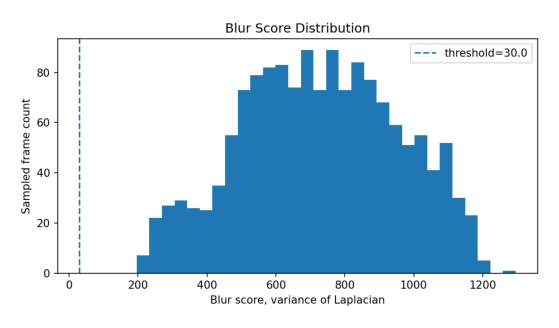

egocentric_bad_frame_ratio.png


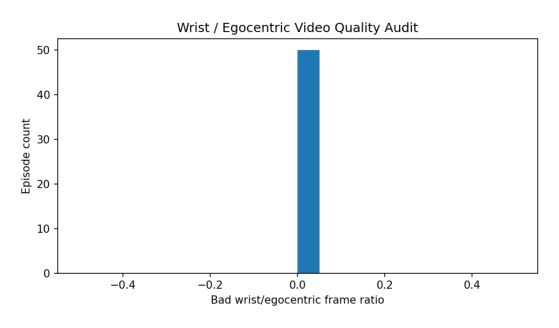

exposure_score_distribution.png


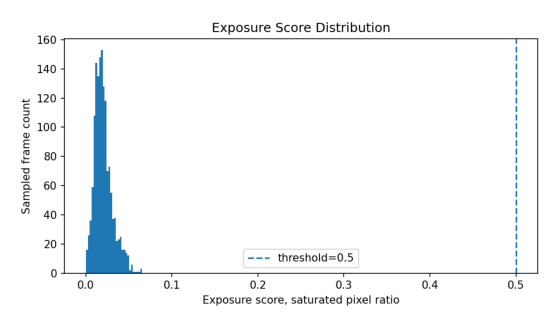

joint_velocity_audit.png


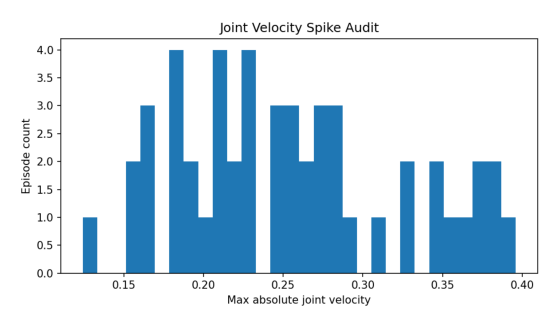

trajectory_length_distribution.png


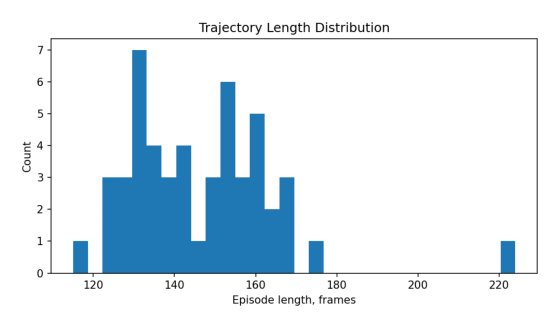

In [31]:
fig_dir = PROJECT_DIR / "outputs" / "figures"

if not fig_dir.exists():
    print("No figure directory found:", fig_dir)
else:
    for path in sorted(fig_dir.glob("*.png")):
        print(path.name)
        img = plt.imread(path)
        plt.figure(figsize=(8, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.show()


## 12. Diagnose video rejection reasons


In [32]:
from collections import Counter

report_path = PROJECT_DIR / "outputs" / "audit_report.json"

with open(report_path, "r", encoding="utf-8") as f:
    reports = json.load(f)

reason_counts = Counter()
blur_scores, exposure_scores, frame_diffs = [], [], []

for r in reports:
    for fr in r["egocentric_video_report"]["frame_reports"]:
        for reason in fr["reasons"]:
            reason_counts[reason] += 1
        blur_scores.append(fr["blur_score"])
        exposure_scores.append(fr["exposure_score"])
        if fr["frame_difference"] is not None:
            frame_diffs.append(fr["frame_difference"])

print("Video rejection reason counts:", reason_counts)

def stats(name, values):
    if not values:
        print(name, "no values")
        return
    arr = np.asarray(values)
    print(
        f"{name}: min={arr.min():.4f}, mean={arr.mean():.4f}, "
        f"median={np.median(arr):.4f}, max={arr.max():.4f}"
    )

stats("Blur", blur_scores)
stats("Exposure", exposure_scores)
stats("Frame diff", frame_diffs)


Video rejection reason counts: Counter()
Blur: min=195.8436, mean=728.7578, median=726.9100, max=1295.3803
Exposure: min=0.0002, mean=0.0204, median=0.0188, max=0.0655
Frame diff: min=1.8088, mean=22.3540, median=21.8845, max=53.6917


## 13. Visualize wrist-camera frames


episode_000000_wrist_frames.png


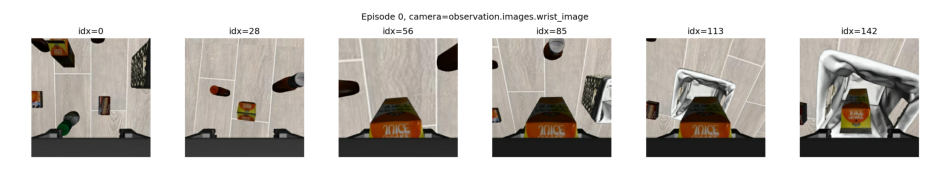

In [33]:
os.chdir(PROJECT_DIR)

subprocess.check_call([
    sys.executable,
    "scripts/visualize_episode.py",
    "--config",
    "configs/curation_colab.yaml",
    "--episode-id",
    "0",
    "--num-frames",
    "6",
])

vis_paths = sorted((PROJECT_DIR / "outputs" / "figures").glob("*wrist_frames.png"))
for path in vis_paths[-3:]:
    print(path.name)
    img = plt.imread(path)
    plt.figure(figsize=(12, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


## 14. Run curation


In [34]:
os.chdir(PROJECT_DIR)

subprocess.check_call([
    sys.executable,
    "scripts/curate_dataset.py",
    "--config",
    "configs/curation_colab.yaml",
])


0

## 15. Inspect curated manifest and arrays


,episode_id,kept,drop_reasons,num_original_steps,num_valid_aligned_steps,array_path
0,0,True,,143,143,outputs/curated_arrays/episode_000000.npz
1,1,True,,148,148,outputs/curated_arrays/episode_000001.npz
2,2,True,,141,141,outputs/curated_arrays/episode_000002.npz
3,3,True,,130,130,outputs/curated_arrays/episode_000003.npz
4,4,True,,132,132,outputs/curated_arrays/episode_000004.npz


,count
kept,
True,50


Curated array files: 50

Sample curated file: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline/outputs/curated_arrays/episode_000000.npz
Keys: ['states', 'states_smooth', 'timestamps', 'original_indices', 'actions']
states (143, 8) float32
states_smooth (143, 8) float32
timestamps (143,) float64
original_indices (143,) int64
actions (143, 7) float32


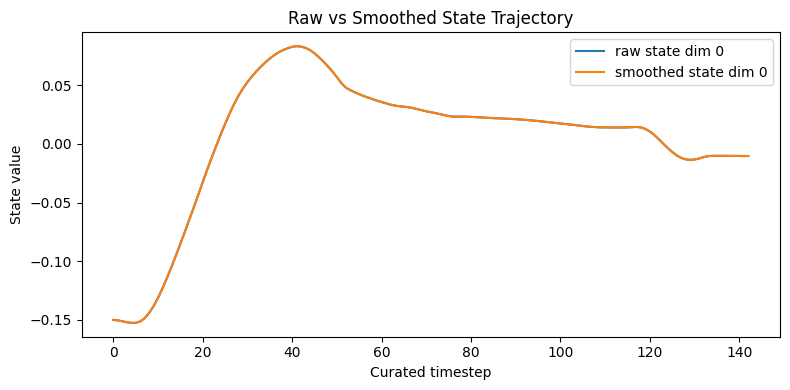

In [35]:
manifest_path = PROJECT_DIR / "outputs" / "curated_manifest.json"

with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)

manifest_df = pd.DataFrame([
    {
        "episode_id": m["episode_id"],
        "kept": m["kept"],
        "drop_reasons": ", ".join(m["drop_reasons"]),
        "num_original_steps": m["num_original_steps"],
        "num_valid_aligned_steps": m["num_valid_aligned_steps"],
        "array_path": m.get("array_path", ""),
    }
    for m in manifest
])

display(manifest_df.head())
display(manifest_df["kept"].value_counts())

curated_dir = PROJECT_DIR / "outputs" / "curated_arrays"
curated_files = sorted(curated_dir.glob("*.npz"))
print("Curated array files:", len(curated_files))

if curated_files:
    sample_npz = curated_files[0]
    data = np.load(sample_npz)
    print("\nSample curated file:", sample_npz)
    print("Keys:", data.files)
    for k in data.files:
        print(k, data[k].shape, data[k].dtype)

    states = data["states"]
    states_smooth = data["states_smooth"]

    plt.figure(figsize=(8, 4))
    dim = 0
    plt.plot(states[:, dim], label="raw state dim 0")
    plt.plot(states_smooth[:, dim], label="smoothed state dim 0")
    plt.title("Raw vs Smoothed State Trajectory")
    plt.xlabel("Curated timestep")
    plt.ylabel("State value")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No curated arrays found. Check thresholds or audit filter reasons.")


## 16. Export Label Studio task stubs


In [36]:
os.chdir(PROJECT_DIR)

subprocess.check_call([
    sys.executable,
    "scripts/export_label_studio_tasks.py",
    "--config",
    "configs/curation_colab.yaml",
    "--manifest",
    "outputs/curated_manifest.json",
    "--out",
    "outputs/label_studio_tasks.json",
])

tasks_path = PROJECT_DIR / "outputs" / "label_studio_tasks.json"
with open(tasks_path, "r", encoding="utf-8") as f:
    tasks = json.load(f)

print("Number of task stubs:", len(tasks))
print(json.dumps(tasks[:3], indent=2))


Number of task stubs: 50
[
  {
    "data": {
      "episode_id": 0,
      "repo_id": "lerobot/libero_object_image",
      "wrist_image_key": "observation.images.wrist_image",
      "array_path": "outputs/curated_arrays/episode_000000.npz"
    },
    "meta": {
      "num_original_steps": 143,
      "num_valid_aligned_steps": 143
    }
  },
  {
    "data": {
      "episode_id": 1,
      "repo_id": "lerobot/libero_object_image",
      "wrist_image_key": "observation.images.wrist_image",
      "array_path": "outputs/curated_arrays/episode_000001.npz"
    },
    "meta": {
      "num_original_steps": 148,
      "num_valid_aligned_steps": 148
    }
  },
  {
    "data": {
      "episode_id": 2,
      "repo_id": "lerobot/libero_object_image",
      "wrist_image_key": "observation.images.wrist_image",
      "array_path": "outputs/curated_arrays/episode_000002.npz"
    },
    "meta": {
      "num_original_steps": 141,
      "num_valid_aligned_steps": 141
    }
  }
]


## 17. Generate Phase 2 results write-up


In [37]:
result_md = PROJECT_DIR / "docs" / "RESULTS_PHASE2.md"
result_md.parent.mkdir(parents=True, exist_ok=True)

num_audited = len(audit_df)
num_keep = int(audit_df["keep_candidate"].sum())
mean_len = float(audit_df["num_steps"].mean())
min_len = int(audit_df["num_steps"].min())
max_len = int(audit_df["num_steps"].max())
max_vel_min = float(audit_df["max_abs_joint_velocity"].min())
max_vel_max = float(audit_df["max_abs_joint_velocity"].max())
mean_bad = float(audit_df["bad_frame_ratio"].mean()) if audit_df["bad_frame_ratio"].notna().any() else None
filter_counts = audit_df["filter_reasons"].value_counts(dropna=False).to_dict()

content = f'''# Phase 2 Results

## Dataset

- Dataset: `lerobot/libero_object_image`
- Audited episodes: {num_audited}
- Selected wrist/egocentric stream: `{metadata["keys"]["wrist_image_key"]}`
- State key: `{metadata["keys"]["state_key"]}`
- Action key: `{metadata["keys"]["action_key"]}`
- Timestamp key: `{metadata["keys"]["timestamp_key"]}`

## Teleoperation audit

The audited episodes have trajectory lengths between {min_len} and {max_len} frames, with an average length of {mean_len:.2f} frames.

The maximum absolute joint/state velocity across episodes ranged from {max_vel_min:.4f} to {max_vel_max:.4f} under the current finite-difference estimate.

The audit checks for:

- NaN/Inf state values
- per-dimension state min/max/mean/std
- timestamp gaps
- finite-difference velocity spikes

## Egocentric / wrist-camera audit

The wrist-camera audit sampled frames with stride `{metadata["thresholds"]["video_frame_stride"]}` and computed:

- blur score using variance of Laplacian
- exposure saturation ratio
- adjacent-frame difference for frozen-frame detection

Mean bad-frame ratio: {mean_bad}

Video rejection reason counts:

```text
{metadata.get("video_reason_counts", {})}
```

## Curation result

Candidate episodes kept by the current filters: {num_keep} / {num_audited}

Filter reason counts:

```text
{filter_counts}
```

The curation step saves a manifest with `original_indices` and `valid_alignment_mask`, so downstream training can preserve the mapping between robot state, action, timestamp, and wrist-camera frame.

## Interpretation

Teleoperation filtering is mostly numerical and kinematic: short episodes, invalid states, timestamp gaps, and unrealistic velocity spikes.

Egocentric filtering is perceptual and threshold-sensitive. Blur/exposure/frozen-frame thresholds should be calibrated using score distributions and manual visualization before dropping full episodes.

## Next steps

- run the audit on all episodes by setting `max_episodes: null`
- manually inspect frames near the blur/exposure thresholds
- export real video clips for Label Studio rather than task stubs
- add object visibility and task-success labels
- train a small wrist-camera success detector
'''

result_md.write_text(content, encoding="utf-8")
print("Wrote:", result_md)
print(result_md.read_text())


Wrote: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline/docs/RESULTS_PHASE2.md
# Phase 2 Results

## Dataset

- Dataset: `lerobot/libero_object_image`
- Audited episodes: 50
- Selected wrist/egocentric stream: `observation.images.wrist_image`
- State key: `observation.state`
- Action key: `action`
- Timestamp key: `timestamp`

## Teleoperation audit

The audited episodes have trajectory lengths between 115 and 224 frames, with an average length of 146.62 frames.

The maximum absolute joint/state velocity across episodes ranged from 0.1242 to 0.3960 under the current finite-difference estimate.

The audit checks for:

- NaN/Inf state values
- per-dimension state min/max/mean/std
- timestamp gaps
- finite-difference velocity spikes

## Egocentric / wrist-camera audit

The wrist-camera audit sampled frames with stride `5` and computed:

- blur score using variance of Laplacian
- exposure saturation ratio
- adjacent-frame difference for frozen-frame detection

Mean bad-frame ra

## 18. Zip final Phase 2 repo back into Google Drive


In [38]:
FINAL_ZIP = DRIVE_WORKDIR / "openarm-data-pipeline-final-colab-drive.zip"

if FINAL_ZIP.exists():
    FINAL_ZIP.unlink()

shutil.make_archive(
    str(FINAL_ZIP).replace(".zip", ""),
    "zip",
    root_dir=str(DRIVE_WORKDIR),
    base_dir="openarm-data-pipeline",
)

print("Created:", FINAL_ZIP)
print("Size MB:", FINAL_ZIP.stat().st_size / 1e6)


Created: /content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline-final-colab-drive.zip
Size MB: 1.716717


## 19. Optional download

The final zip is already saved in Google Drive:

```text
/content/drive/MyDrive/Colab Notebooks/openarm-data-pipeline-final-colab-drive.zip
```

Run the cell below only if you also want to download it to your local machine.


In [39]:
from google.colab import files

FINAL_ZIP = DRIVE_WORKDIR / "openarm-data-pipeline-final-colab-drive.zip"
if FINAL_ZIP.exists():
    files.download(str(FINAL_ZIP))
else:
    print("Final zip not found yet. Run the previous cell first.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>